# Máquinas Térmicas – Lección 14  
## Modelado termofluídico de un condensador (carcasa y tubos)

**Autor:** Camilo Bayona  
**Fecha:** 20/11/2025


## Objetivos de aprendizaje

- Formular y aplicar **balances de masa** y **energía** para un **condensador shell-&-tube**.  
- Identificar regímenes de **flujo interno** (agua en tubos) y **flujo cruzado externo** (vapor en carcasa) mediante **Re**, **Pr**, **Nu**.  
- Calcular **coeficientes de convección** (agua/vapor), **conducción** en pared del tubo y **pérdidas** por **convección natural** a ambiente.  
- Construir el **modelo 0D transitorio** acoplado y describir su **implementación numérica** (p. ej. RK4).  


 ## 1. Esquema físico y variables

- **Carcasa (shell)**: flujo de vapor compresible, densidad constante aproximada en régimen normal. La carcasa contiene los componentes internos del condensador, incluyendo las placas de soporte de los tubos , las placas tubulares , los tubos , el pozo caliente y las tuberías de extracción [33].

- **Haz de tubos**: Los tubos que pasan por el condensador se ensamblan formando un haz, estos se montan sobre placas tubulares.

- **Tubos**: Flujo de agua refrigerante (fluido incompresible).

- **Geometría**: banco de tubos en arreglo alineado.

- **Áreas características**:
  - **$A_1$**: tubería de ingreso del agua al water box.
  - **$A_2$**: tapa de ingreso de vapor.
  - **$A_3$**: sección de un tubo.
  - **$A_4$**: tubería de salida del condensado.
  - **$A_{int}$**: área interna total de todos los tubos con flujo de agua refrigerante.
  - **$A_{ext}$**: área interna externa de la carcasa donde hay flujo de vapor.
  - **$A_E$**: árewa externa de la carcasa expuesta al ambiente (perdidas).

- **Diámetros / longitudes / pasos**
  - **D_1**: diámetro interior del tubo.
  - **D_2**: diámetro exterior del tubo.
  - **ST**: straight pitch (pitch entre centros, en dirección transversal).
  - **D**: diámetro interno de la carcasa.
  - **L**: longitud efectiva del haz de tubos y carcasa (longitud de intercambio).



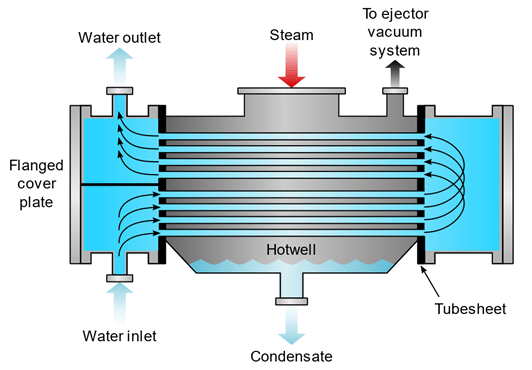

*Figura 1 : Esquemático del condensador de superficie.*


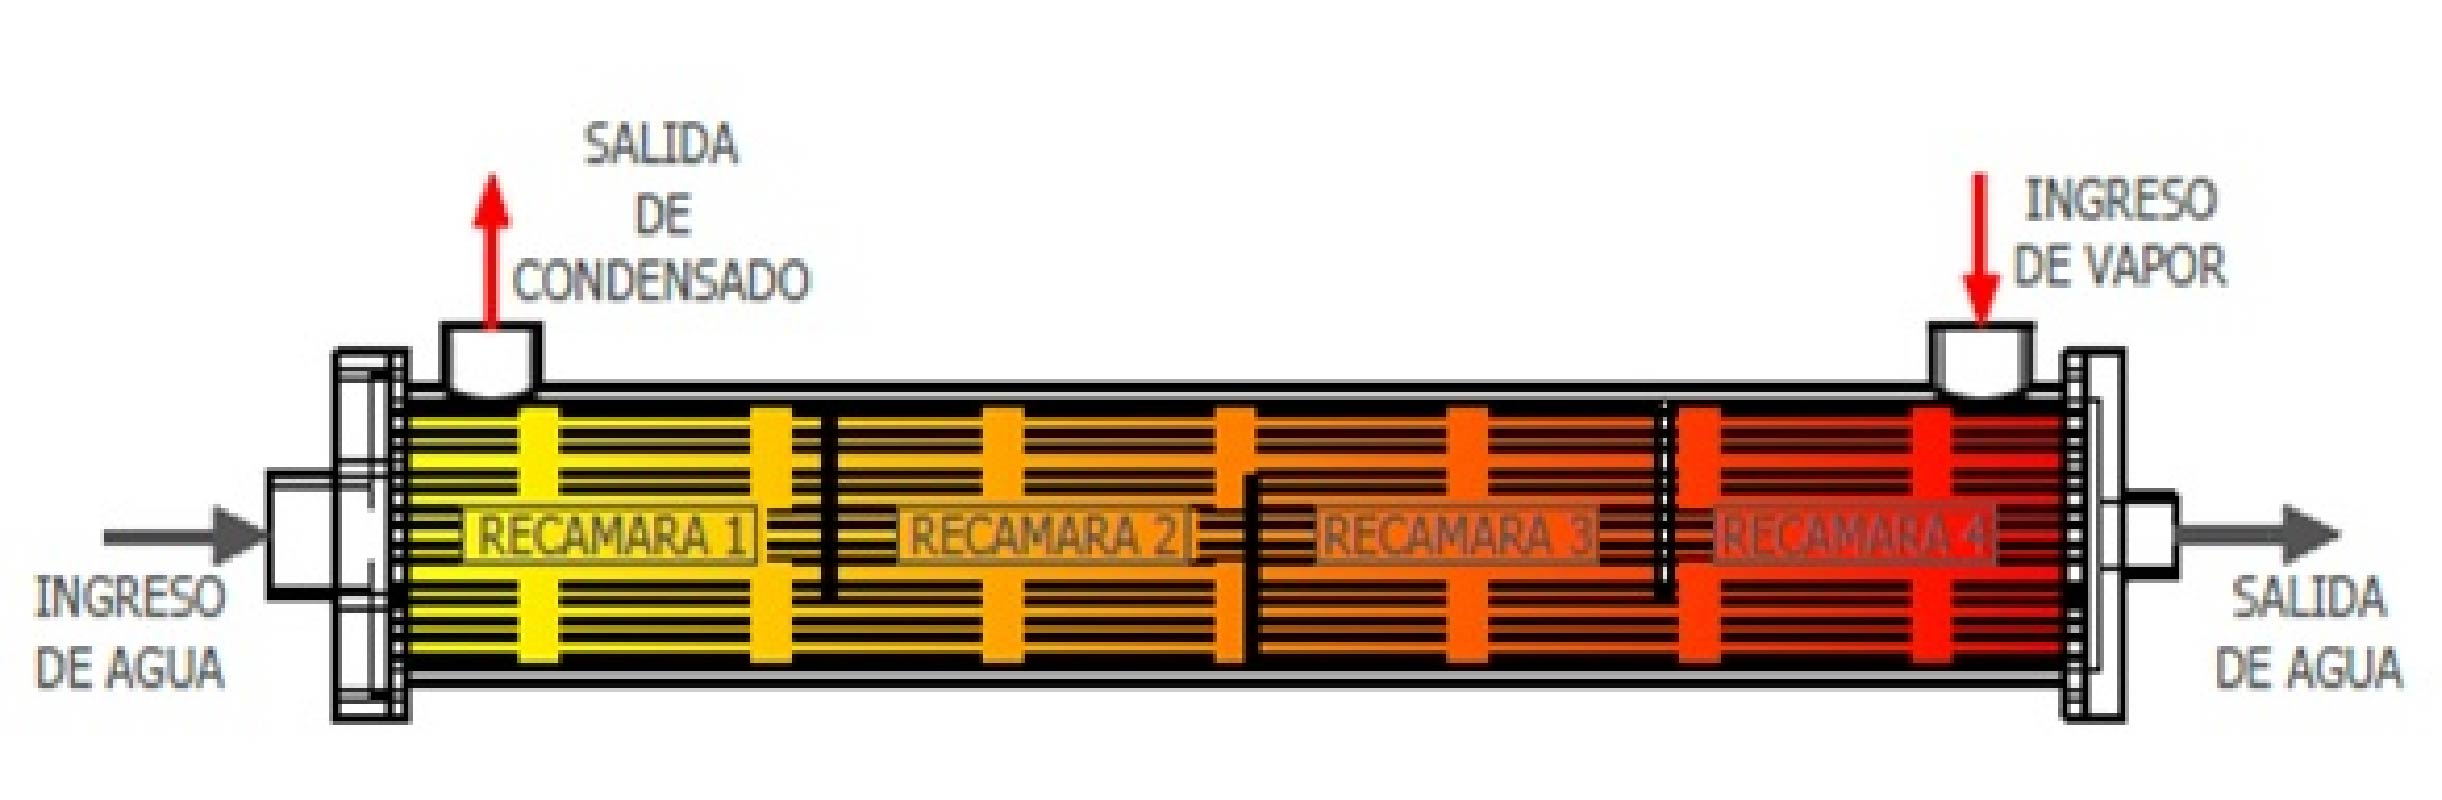

*Figura 1 : Esquemático del condensador de vapor de carcasa y tubos.*

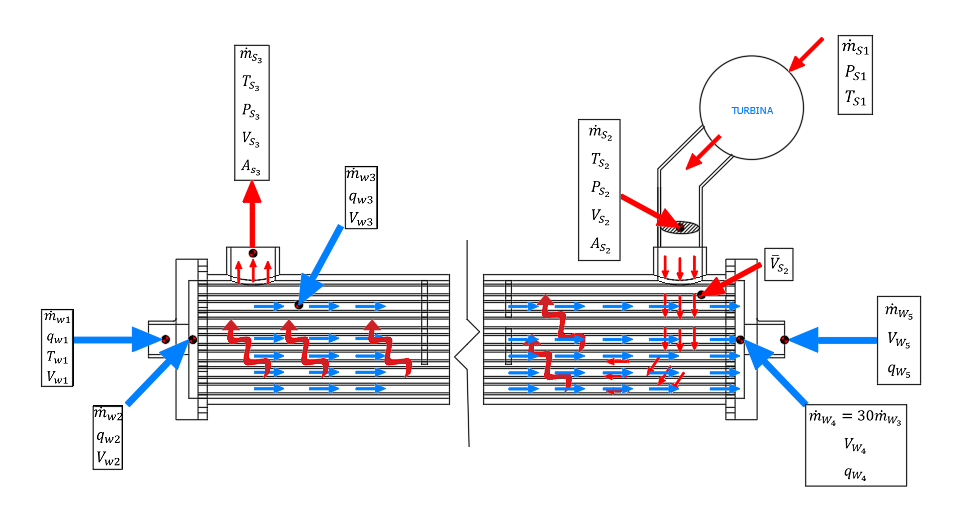

*Figura 2 : Detalle de los flujos de vapor y agua en el condensador.*

En la Figuras 1 y 2 se muestra una versión esquemática del condensador instalado en la planta térmica, que incluye la carcasa y el banco de tubos, así como el etiquetado de sus flujos másicos y energéticos.
Los flujos considerados en el análisis son los que tienen que ver con el vapor de agua en la carcasa y con el agua refrigerante en los tubos.
Primero, demostramos la aplicación del equilibrio de masa en dichos flujos.
Luego, desarrollamos el balance energético en cada uno de los componentes, incluyendo la transferencia de calor del vapor hacia los tubos y el agua refrigerante, así como la pérdida de calor del vapor a la atmósfera circundante a través de la carcasa.El acoplamiento de las ecuaciones de balance de masa y energía da como resultado un modelo de 0 dimensiones que describe la dinámica de fluidos, la transferencia de calor y la variación de las temperaturas de los fluidos dentro del condensador.
El modelo se limita al rango de funcionamiento normal del condensador de vapor. Sin embargo, en el presente trabajo se pretende dar respuesta a un cambio en las condiciones operativas del equipo.
El modelo se enfoca en componentes primarios y evita la descripción del comportamiento estructural de las partes sólidas del condensador, que no son esenciales en la operación.
Un análisis excluido del modelo es el cambio de fase en el vapor para determinar la cantidad de condensado.
Aunque éste es un fenómeno crucial en la operación del condensador, y su interés viene dado por la cantidad de calor cedido por el vapor en el cambio de fase, su inclusión se propone como trabajo futuro debido a la compleja no-linealidad del sistema y a la motivación hidrodinámica de la problemática presente en la planta térmica.
Efectivamente, la aplicación de las ecuaciones de equilibrio en los componentes del condensador se presenta en los siguientes párrafos.

## 2. Balance de Masa
La ecuación general del balance de masa en un sistema cerrado  viene dada por
$$
    \frac{d M }{d t} = \sum_i \dot{m}_i \tag{1}
$$
donde $M$ es la masa total del sistema y $\dot{m}_i$ es el i-ésimo flujo (positivo entrante, negativo saliente) del sistema.
Este flujo másico se puede calcular sabiendo la velocidad promedio del flujo $\overline{V}$, la densidad del fluido $\rho$ y el área de sección transversal del canal de flujo $A$, de la forma $\dot{m}=\rho\overline{V}{A}$.

En el caso de un líquido fluyendo en el interior de una tubería, donde no hay acumulación ni compresibilidad del fluido, se tiene que el flujo másico a la entrada es igual a flujo másico de la salida $\dot{m}_1=\dot{m}_2$.
Por el contrario, en el caso del vapor, siendo un gas compresible, se debe evaluar el cambio de masa en el sistema debido a procesos de compresión o expansión.
Sin embargo, debido a que la expansión del vapor dentro de la carcasa no es significativa, dicho proceso de desprecia en el presente trabajo.

### 2.1 Hidráulica del agua refrigerante

Un esquemático de las principales etapas del flujo de agua refrigerante en el condensador se muestra en la Figura 3.

En éste modelo, la identificación de las condiciones del flujo dentro de los tubos es esencial para la cuantificación de la transferencia de calor.
Por lo tanto, se analizan a continuación las condiciones de: (1) entrada del agua refrigerante al equipo, (2) la distribución de agua en el cabezal del banco de tubos, y (3) el interior de cada tubo.
En dicha figura, se presenta también un corte transversal del condensador donde se muestran las áreas transversales de sus elementos: siendo $A_1$ el área transversal de la tubería de ingreso al condensador, $A_2$ el área transversal de la tapa de ingreso al condensador y $A_3$ el área transversal de un solo tubo BGW 14.


Para realizar el análisis del flujo de agua dentro del condensador se parte por determinar la condición de ingreso del agua proveniente de la torre de enfriamiento, la cual es impulsada por una bomba.
Esta condición es un dato conocido, siendo que la planta térmica cuenta con sensores que permiten medir dichas condiciones de entrada al equipo.
Específicamente, se puede obtener el flujo másico de entrada $\dot{m}_{W1}=\rho_{W1}\dot{q}_{W1}$, a partir de la medición del caudal $\dot{q}_{W1}$ y el dato de densidad del agua $\rho_{W1}$.

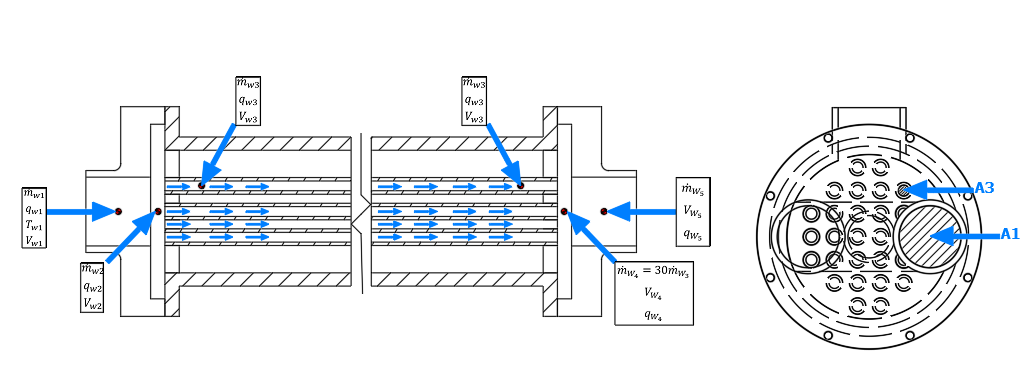

*Figura 3 : Detalle de la sección de ingreso y salida del agua en el condensador.*

Una vez obtenido el caudal de ingreso se procede a realizar los balances másicos con el fin de obtener la velocidad del fluido en la tapa del condensador y en los tubos, donde la sección transversal de la tubería es menor y por consiguiente, varía la velocidad del fluido.
Partiendo de la ecuación de balance de masa, y sabiendo que no hay acumulación de masa dentro de la tubería, se puede determinar el caudal en la sección transversal de la tapa de ingreso al condensador.
Esto es, se sabe que $\dot{m}_{W1}=\dot{m}_{W2}$, siendo $\dot{m}_{W2}$ el flujo másico en la tapa distribuidora. Se puede entonces calcular la velocidad promedio $\overline{V}_{W2}$ con el dato del área transversal de la tapa $A_2$.
El flujo másico en dicha tapa se distribuye en cada uno de los tubos del interior del condensador.
Por lo tanto, $\dot{m}_{W2}= \rho_{W1}\sum\overline{V}_{Wi}{A_i}$, donde $\overline{V}_{Wi}{A_i}$ es el caudal de un iésimo tubo.
Siendo que el condensador cuenta en su interior con 30 tubos BGW 14, se obtiene de la ecuación anterior un valor aproximado de la velocidad del agua que fluye en un solo tubo:
$$
\overline{V}_{W3}=\frac{\dot{m}_{W2}}{30\rho_{W1}{A_3}}. \tag{2}
$$

Obtenida la velocidad del agua al interior de un tubo, se calcula el número de Reynolds del flujo de agua refrigerante.
Este número permite calcular el coeficiente de transferencia de calor por convección al interior de los tubos, e indica el régimen del flujo, ya sea flujo laminar, transicional o turbulento.
En general, el número de Reynolds está definido como la relación
$$
\text{Re}=\frac{\rho{D}\overline{V}}{\mu}, \tag{3}
$$
donde $D$ es una longitud característica (usualmente asociada con el diámetro de la tubería) y $\mu$ es la viscosidad del fluido.
En particular, para el flujo al interior de un tubo, el número de Reynolds viene dado por $\text{Re}=\rho_{W1}{D}_{1}\overline{V}_{W3}/\mu_{W1}$, donde ${D}_{1}$ es el diámetro interno de los tubos BWG y $\mu_{W1}$ es la viscosidad del agua líquida.

Para determinar las condiciones de salida del agua refrigerante se realiza el análisis de los balances de flujos másicos de forma similar al realizado anteriormente para la entrada del agua.
Es fácil observar que el caudal (y la velocidad) en la tapa de salida es el mismo que en la tapa de entrada debido a la conservación de masa.
También, que el caudal (y la velocidad) del agua de refrigeración en la salida del condensador es equivalente al de entrada.


### 2.2 Hidrodinámica del vapor de agua

Para realizar el análisis del flujo del vapor al interior del condensador se parte de los datos sensados por la planta térmica.
En el caso del vapor, se pueden obtener las mediciones del flujo másico de vapor en la turbina, la temperatura y la presión con la cual ingresa el vapor a la turbina, como se muestra en la *Figura 2*.
Estos datos son usados para calcular las condiciones de ingreso del vapor al condensador.


Partiendo de la información medida y suministrada, se realiza el planteamiento de las ecuaciones necesarias para determinar las condiciones del flujo en el banco de tubos.
En el caso del balance de masa en la tubería de vapor, se sabe que $\dot{m}_{S1}=\dot{m}_{S2}$, siendo $\dot{m}_{S1}$ el flujo medido de masa ingresando a la turbina y $\dot{m}_{S2}$ el flujo de masa de vapor que entra al condensador.
Sabiendo el área de sección transversal de la tubería de entrada de vapor al condensador $A_2$, y suponiendo una densidad constante del vapor de agua $\rho_{S2}$, se calcula la velocidad promedio de entrada del vapor como

$$
\overline{V}_{S2}=\frac{\dot{m}_{S1}}{\rho_{S2}A_{2}} \tag{4}
$$

A partir de la ecuación anterior se puede determinar la velocidad del vapor pasando a través del banco de tubos.
El arreglo del banco de tubos es un arreglo cuadrado con los tubos alineados entre sí.
La distancia entre centros de tubos es de 18 mm, tomándose esta distancia como longitud característica.
Denotándose $S_T$ como la distancia radial entre los centros de los tubos y $D_2$ el diámetro exterior de un tubo, la velocidad máxima del vapor a través del banco de tubos se obtiene mediante la expresión
$$
V_{max}=\frac{ST}{ST-D_{2}}{\overline{V}_{S2}} \tag{5}
$$
Con esta velocidad máxima se calcula el número de Reynolds del vapor usando la ecuación (\ref{eq:reynolds}), asumiendo $D_2$ como la longitud característica del flujo.

## 3. Balance de Energía (0D, transitorio)

La ecuación general del balance de energía en un sistema cerrado viene dada por:
$$
 \rho c_p\frac{d T }{d t} \mathcal{V} = \sum_i \dot{m}_i c_p T_i + \sum_j \dot{Q}_j \tag{5}
 $$
donde $T$ es la temperatura del sistema, $\mathcal{V}$ es el volúmen del sistema, $\dot{m}_i c_p T_i$ es la energía transportada por el i-ésimo flujo (positivo entrante, negativo saliente) sobre el sistema y $\dot{Q}_j$ es el j-ésimo flujo de calor sobre el sistema.
La aplicación particular de esta ecuación sobre el agua refrigerante y el vapor se describe a continuación.

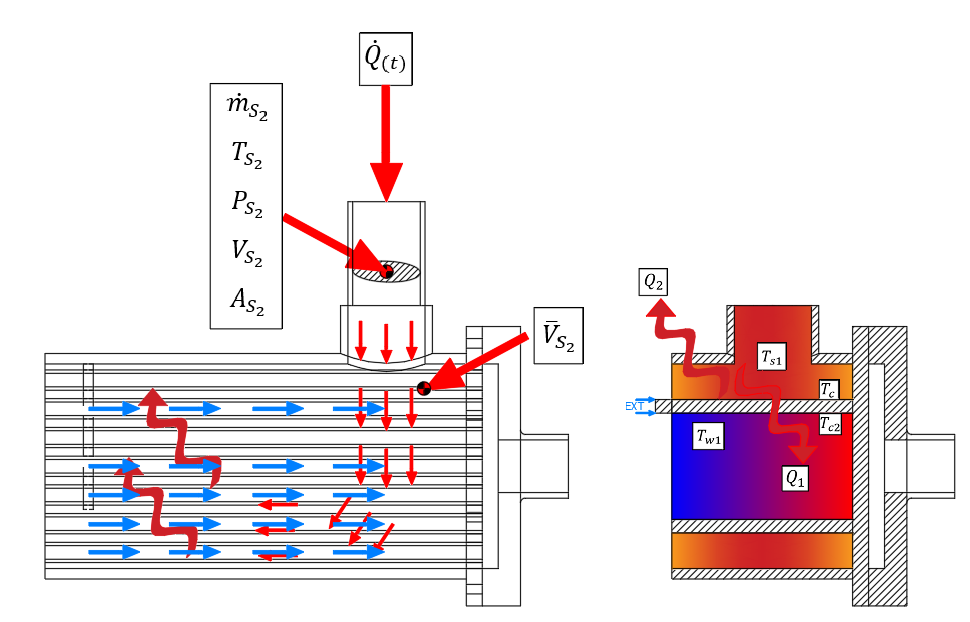

*Figura 4 : Esquema de los flujos de calor en el condensador*

### 3.1 Agua refrigerante (en tubos)

Se realiza entonces el balance energético para el agua refrigerante según el esquema mostrado en la *Figura 4*.
El resultado de este análisis es la cuantificación de los cambios de temperatura dentro de los tubos del condensador.
Definiendo $T_W(t)$ la temperatura del agua al interior de los tubos, $T_{W1}$ la temperatura (conocida) de entrada del agua y $T_{W5}$ la temperatura (desconocida) del agua a la salida, $c_{pW}$ el calor específico a presión constante del agua líquida, $\dot{Q}_{1}$ el flujo de calor transferido del vapor al agua y $\mathcal{V}$ el volumen total interior de los tubos, el balance energético del agua resulta en
\begin{align}
\rho \mathcal{V}c_{pW}\frac{dT_{W}}{dt}=30\ \dot{m}_{W3}c_{pW}T_{W1}-\dot{m}_{W5}c_{pW}T_{W5}+\dot{Q}_{1} \tag{6}
\end{align}
En éste trabajo se asume que la temperatura a la salida del agua será la misma que la temperatura dentro del tubo $T_{W5} = T_{W}$.

#### 3.1.1 Números adimensionales
Para determinar el coeficiente de transferencia de calor por convección que influye en la cantidad $\dot{Q}_{1}$ es necesario calcular otros número adimensionales.
En primera medida, se debe calcular el número de Prandtl.
Este es un número adimensional proporcional al cociente entre la difusividad de momento (viscosidad) y la difusividad térmica:
\begin{align}
\text{Pr}=\frac{\nu}{\alpha}=\frac{c_p\mu}{K} \tag{7}
\end{align}
donde $\nu$ es la viscosidad cinemática, $\alpha$ es la difusividad térmica y $K$ es la conductividad térmica del fluido.

También se realiza el cálculo del número de Nusselt, el cual representa el gradiente del perfil adimensional de la temperatura.
Este es un número adimensional utilizado para caracterizar la transferencia de calor por convección.
Se basa en el análisis dimensional y se utiliza por parámetros de similitud para determinar la transferencia de calor de una superficie caliente por la que se convecta el fluido.
Dicho número se define como:
\begin{align}
\text{Nu}=\frac{h}{DK} \tag{8}
\end{align}
donde $h$ es el coeficiente de transferencia de calor por convección, $D$ es una dimensión característica (que se define como el diámetro de la tubería).
El número de Nusselt es la medida de la relación que existe entre la transferencia de calor por convección y la transferencia de calor por conducción.
Las relaciones de transferencia de calor por convección generalmente se expresan escribiendo el número de Nusselt en función del número de Reynolds y del número de Prandtl.
Para el cálculo del número de Nusselt de un fluido que fluye en el interior de un tubo, la literatura recomienda la ecuación de Chilton-Colburn:
\begin{align}
\text{Nu}=0.023\text{Re}^{0.8}\text{Pr}^{0.4} \tag{9}
\end{align}
Entonces una vez obtenidos el número de Reynolds, Prandtl y Nusselt con las expresiones previamente definidas, se procede a utilizar la ecuación (\ref{eq:nusselt}) para determinar el coeficiente de transferencia de calor por convección del agua refrigerante.
Efectivamente, la transferencia de calor por convección en el interior del tubo se puede modelar por medio de la siguiente ecuación:
\begin{align}
\dot{Q}_1= h_{W}(T_{C2}-T_{W})A_{int} \tag{10}
\end{align}
donde $T_{C2}$ es la temperatura de la superficie interior del tubo, $h_{W}$ es el coeficiente de transferencia de calor por convección en el agua interior y $A_{int}$ es el área de transferencia de calor del interior del tubo.
La ecuación de calor por convección  permite determinar la temperatura de la superficie interior del tubo.


### 3.2 Vapor de agua (en carcasa)

Se plantea el balance energético que describe la variación de la temperatura del vapor que fluye en el interior del condensador.
Definiendo $\mathcal{V}_S$ como el volúmen interior de la carcasa, $T_S$ la temperatura del vapor a su paso por los tubos, $T_{S2}$ la temperatura del vapor a la entrada, $T_{S3}$ la temperatura del vapor a la salida, $\rho_{S}$ la densidad del vapor, $c_{pS}$ el calor específico del vapor a presión constante, $\dot{Q}_{1}$ el flujo de calor perdido por el vapor hacia el agua refrigerante, y $\dot{Q}_{2}$ el flujo de calor perdido hacia el medio ambiente a través de la carcasa, el balance de energía en el vapor es el siguiente:

\begin{align}
\rho_S\mathcal{V}_S{c}_{pS}\frac{d\rho T_{S3}(t)}{dt}=\dot{m}_{S2}{c}_{pS}{T}_{S2}-\dot{m}_{S3}{c}_{pS}{T}_{S3}-\dot{Q}_{1}-\dot{Q}_{2} \tag{11}
\end{align}

En éste trabajo se considera que la temperatura de salida del vapor es la misma temperatura a su paso por los tubos, ${T}_{S3}={T}_{S}$.

Para determinar los flujos de calor $\dot{Q}_1$ y $\dot{Q}_{2}$, se emplean las ecuaciones de transferencia de calor por convección.
El procedimiento para calcular dichas cantidades se detalla a continuación.

#### 3.2.1 Números adimensionales

En primera medida, se calcula el flujo de calor transferido por el vapor en su paso a través del banco de tubos. Para ello se plantea la expresión que permite calcular el coeficiente de convección forzada. Usualmente, dicha cantidad se escribe en términos de los números de Reynolds, Prandtl y Nusselt.
El número de Prandtl se calcula usando la ecuación ($7$) con las propiedades del vapor.
La expresión comúnmente usada para calcular el número de Nusselt en términos del Reynolds y Prandtl es la relación de Chilton-Colburn. En el caso particular de vapor fluyendo de manera cruzada a través del banco de tubos, dicha expresión es de la forma:
\begin{align*}
\text{Nu}=C\ (\text{Re})^{m}(\text{Pr})^{n}\left(\frac{\text{Pr}}{\text{Prs}} \right)^{0.25} \tag{12}
\end{align*}
donde que $\text{Prs}$ es el número de Prandtl de película del fluido que se evalua a la temperatura aproximada de la película del fluido sobre la superficie del tubo.
En la literatura se encuentran dispuestos distintos valores para las constantes $C$, $m$ y $n$, las cuales dependen del Reynolds y de la configuración del banco de tubos .
Dichos valores provienen de resultados experimentales.
Para la configuración del arreglo de tubos alineados, se tienen los coeficientes presentados en la siguiente expresión:
\begin{align}
    \text{Nu}(\text{Re},\text{Pr},\text{Prs}) =
     \begin{cases}
       0.9\ \text{Re}^{0.4}\text{Pr}^{0.36}(\text{Pr}/\text{Prs})^{0.25}, &\quad\text{si}\quad\text{Re}\le 100 \\
       0.52\ \text{Re}^{0.5}\text{Pr}^{0.36}(\text{Pr}/\text{Prs})^{0.25}, &\quad\text{si}\quad 100<\text{Re}\le 1000\\
       0.27\ \text{Re}^{0.63}\text{Pr}^{0.36}(\text{Pr}/\text{Prs})^{0.25},  &\quad\text{si}\quad1000<\text{Re}\le 2\times10^5\\
       0.033\ \text{Re}^{0.8}\text{Pr}^{0.8}(\text{Pr}/\text{Prs})^{0.25},  &\quad\text{si}\quad 2\times10^5<\text{Re}\le 2\times10^6
     \end{cases}
     \tag{13}
\end{align}
Dichos valores son específicos para una configuración con un número de tubos menor a $16$ y $0.7<\text{Pr}<500$.

En ese sentido, debido a que el banco de tubos está conformado por menos de 16 filas se debe aplicar el factor de corrección al número Nusselt, $
\text{Nu}|_{NL<16}=F\text{Nu}
$ donde $F$=0.99.
Una vez obtenidos el número de Reynolds, el número de Prandtl y el número de Nusselt corregido, se procede a utilizar la ecuación ($8$) para determinar el coeficiente de transferencia de calor por convección del vapor $h_S$, donde el diámetro externo de los tubos $D_2$ es considerado como la longitud característica.




#### 3.2.2 Convección natural (carcasa–ambiente)
El flujo de calor $\dot{Q}_1$ que se transmite a los tubos, viene dado por la relación
\begin{align}
\dot{Q}_1= h_{S}(T_{S}-T_{C1})A_{ext} \tag{14}
\end{align}
donde $T_C$ es la temperatura en la superficie externa del tubo y $A_{ext}$ es el área de dicha superficie exterior.

En segunda medida, se calcula el flujo de calor perdido por el vapor a la atmósfera en su paso por el condensador.
Se realiza entonces el análisis de la transferencia de calor por convección natural del aire ambiente sobre la superficie de la carcasa del condensador.
Para esto se calculan los números adimensionales de Grashof y Rayleigh que se enuncian a continuación.
El número de Grashof se calcula como
\begin{align}
\text{Gr}=\frac{g\beta(T_S-T_{\infty})L_C^{3}}{\nu^{2}}  \tag{15}
\end{align}
donde $T_{S}$ es la temperatura de la superficie de la carcasa (que igualamos con la del vapor al interior), $T_{\infty}$ es la temperatura ambiente (conocida), $g$ es la aceleración de la gravedad, $L_C$ es una longitud característica (que consideramos como el diámetro de la carcasa) y $\nu$ es la viscosidad cinemática del aire.
El número de Rayleigh se calcula como
\begin{align}
\text{Ra}=\text{Gr}\text{Pr} \tag{16}
\end{align}
Las propiedades del aire ambiente se determinan a la temperatura de película $T_{f}=(T_{S}+T_{\infty})/2$.
Finalmente, se determina el número de Nusselt a partir de la correlación empírica para la convección natural sobre superficies:
\begin{align}
\text{Nu}=\left\{ 0.6+\frac{0.387\
\text{Ra}^{{1}/{6}}}{\lbrack 1+({0.559}/{\text{Pr}})^{{9}/{16}}\rbrack
^{{8}/{27}}}\right\} ^{2}  \tag{17}
\end{align}
Una vez obtenido el número de Nusselt, se calcula el coeficiente de convección natural $h_E$ usando el diámetro de la carcasa $D$ como longitud característica.
Para calcular el calor perdido por convección natural se emplea la relación
\begin{align}
\dot{Q}_{2}= h_EA_{E}(T_{S}-T_{\infty}) \tag{18}
\end{align}
donde el área superficial de la carcasa se calcula como $A_{E}=\pi DL$, siendo $L$ la longitud total de la carcasa.



#### 3.2.3 Intercambio energético a través de la pared del tubo

Planteadas las ecuaciones de transferencia de calor por convección, se hace ahora el análisis de la transferencia de calor por conducción a través de la pared de los tubos:
\begin{align}
\dot{Q}_{1}= KA(T_{C1}-T_{C2}) \tag{19}
\end{align}
donde $K$ es la conductividad térmica del material,  $T_{c(t)}$  es la temperatura en la superficie externa del tubo, $T_{c2(t)}$  hace referencia a la temperatura en la superficie interna del tubo y A es el área de transferencia de calor.
Este calor $\dot{Q}_{1}$ transmitido por conducción en el sólido (tubo) es el mismo transferido por convección desde el vapor o hacia el agua refrigerante.
El área de transferencia de calor por conducción en el tubo es el área exterior equivalente a la sumatoria de las áreas exteriores de todos los tubos que conforman el arreglo del banco de tubos.

## 4. Implementación computacional

En la sección anterior se desarrolló el modelo termo-fluídico del condensador de vapor, en el cual se cuantifica el comportamiento dinámico del agua y el vapor que fluyen por los componentes del condensador de tipo carcasa y tubos.
El modelo completo conduce a un sistema acoplado de varias ecuaciones algebraicas y diferenciales ordinarias ($2$)- ($5$) y ($7$)-($19$).
Además, el modelo matemático dado por esas ecuaciones dinámico (o transitorio) y *0-dimensional*, debido a que gobierna todo el comportamiento temporal y espacial de los fluidos al interior del condensador.
Para completar el modelo, se deben establecer condiciones de compatibilidad entre todos los elementos del análisis: se hace indispensable resolver el sistema acoplado de ecuaciones para obtener un condensador operativo con una respuesta transitoria.


**Incógnitas principales:** $T_W(t)$, $T_S(t)$, $T_{C,1}(t)$, $T_{C,2}(t)$ (si se resuelven explícitas), y campos auxiliares $h_W, h_S, h_E$.  
**Ecuaciones:**  
- Masa → velocidades $\overline V_{W,3}$, $V_{\max}$ → $\mathrm{Re}$.  
- Propiedades → $\mathrm{Pr}$, $\mathrm{Nu}$ → $h$.  
- Compatibilidad de calor → $\dot Q_1$ consistente en (agua, pared, vapor).  
- ODEs de energía → $T_W'(t)$, $T_S'(t)$.

**Condiciones de contorno / iniciales:**  
- $T_W(0)=T_{W,0}$, $T_S(0)=T_{S,0}$.  
- Entradas medidas: $\dot q_{W,1},\,T_{W,1},\,\dot m_{S,1},\,T_{S,2},\,p$.  
- Ambiente: $T_\infty$.  
- Geometría/material: $D_1,D_2,S_T,D,L,K$.  

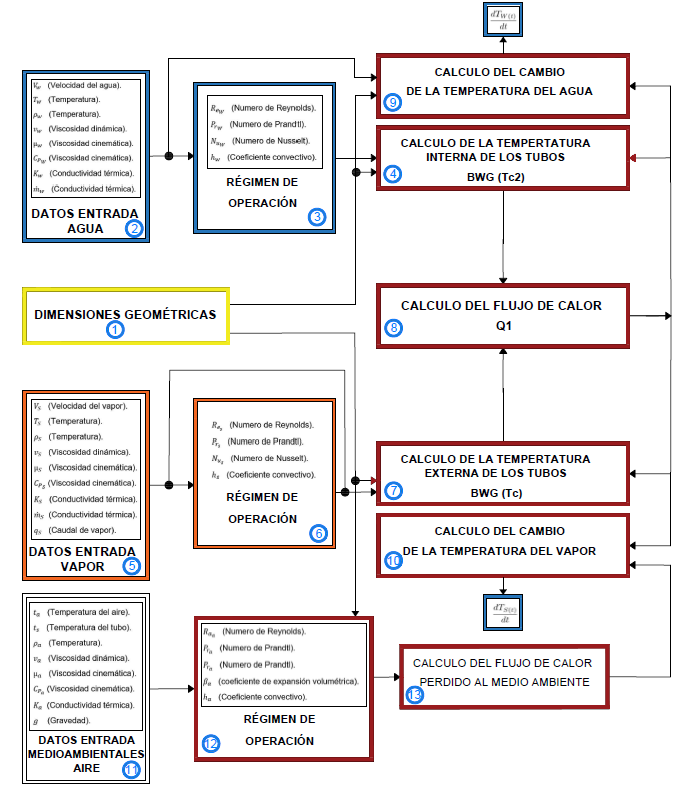

*Figura 5: Diagrama de flujo del modelo computacional del condensador*

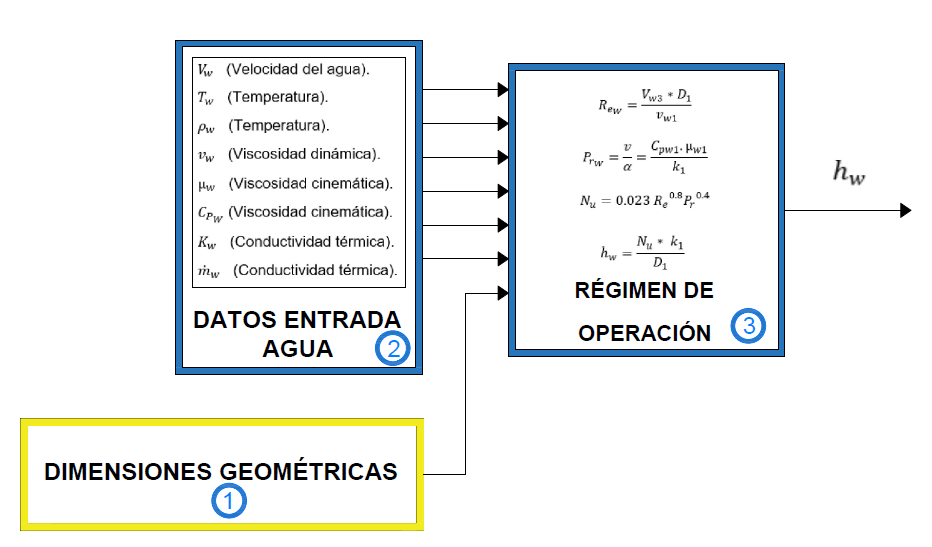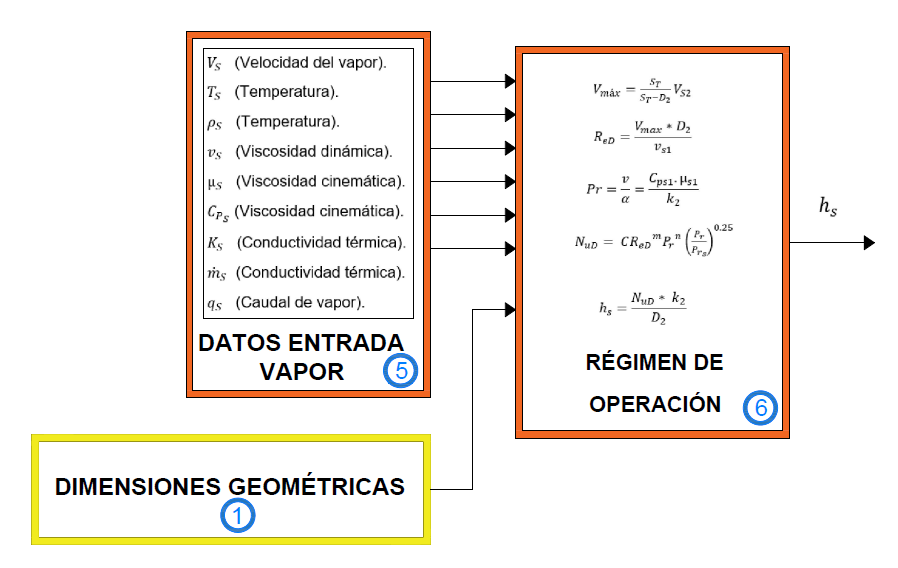

*Figura 6 : Detalle de los bloques de cálculo de los coeficientes de convección forzada*

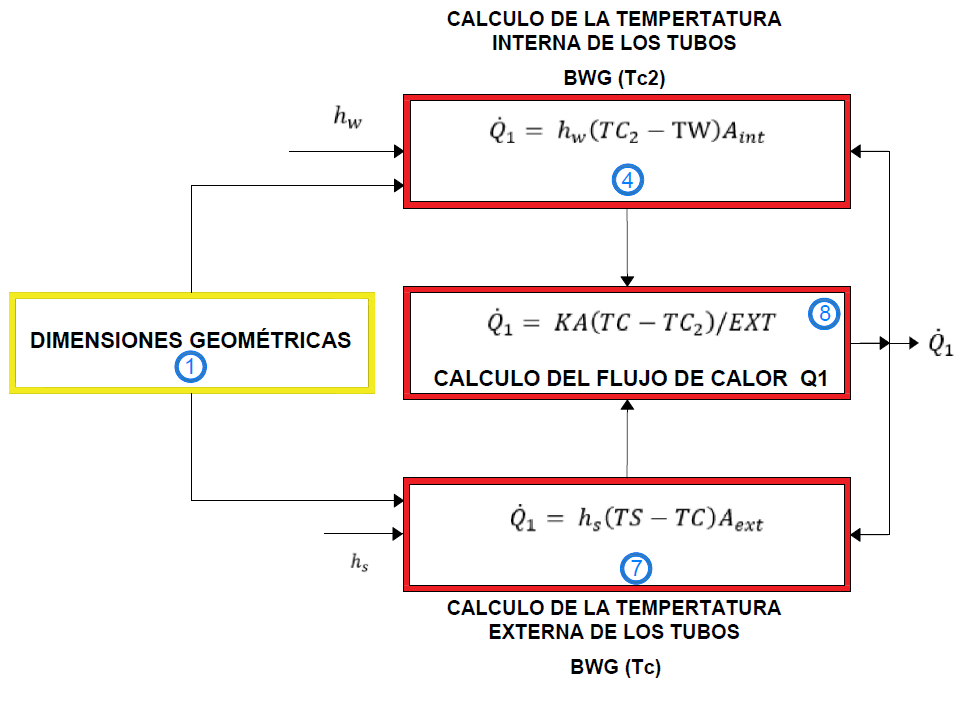

*Figura 7 : Detalle de los bloques de cálculo de los coeficientes de convección forzada*


En esta sección demostramos la resolución del sistema de ecuaciones mediante el álgebra de bloques en un entorno computacional.
De hecho, la descripción teórica del condensador de vapor no puede realizarse de manera analítica, ya que hay pocas situaciones de operación muy simplificadas en las que se puedan obtener soluciones analíticas transitorias.
La única metodología práctica es aproximar la solución de la operación realista del equipo usando métodos numéricos, y calcular esas aproximaciones en una computadora usando una técnica discreta: por lo general, el *método implícito de cuarto orden Runge-Kutta* se usa para la integración numérica de las derivadas, lo que lleva a un sistema lineal de ecuaciones algebraicas que debe resolverse en cada paso de tiempo.

Un enfoque práctico para resolver este sistema lineal de ecuaciones es implementar la solución numérica de las ecuaciones de gobierno basadas en una resolución explícita de sistema lineal por medio del método de Runge-Kutta de cuarto orden en cada paso de tiempo.
Todo lo anterior, con una interfaz gráfica de usuario para construir _diagramas de bloques algebraícos_ que representan las relaciones entre variables y parámetros dadas por las ecuaciones diferenciales de gobierno.
El enfoque hacia el usuario encapsula todos los tratamientos numéricos dentro de bloques algebraícos, haciendo de la programación computacional un ejercicio ágil y descomplicado que está libre de código.

Por lo tanto, se plantea en el presente trabajo el diagrama de bloques general que representa las relaciones dadas por las ecuaciones de gobierno. Dicho diagrama general se muestra en la Figura 5 , donde el condensador completo está representado en un nivel global.
Esto es, cada sub-bloque del diagrama general en la figura representa un grupo de cálculos para resolver las ecuaciones gobernantes del condensador.
Dichos sub-bloques se detallan conceptualmente en las figuras 6 - 7, donde se presentan los subsistemas que realizan los cálculos.
En cada uno de los subsistemas mostrados en las figuras se enumeran las entradas, los parámetros y las salidas del cálculo.
El diagrama general está conformado por 13 bloques elementales que agrupan en su interior diversos subconjuntos de operaciones en los cuales se resuelven en parte las ecuaciones descritas en el apartado anterior.
Por ejemplo, los sub-bloques calculan: los números adimensionales necesarios para determinar los regímenes de operación de los fluidos, coeficientes de convección y las ecuaciones de balance de masa y energía.



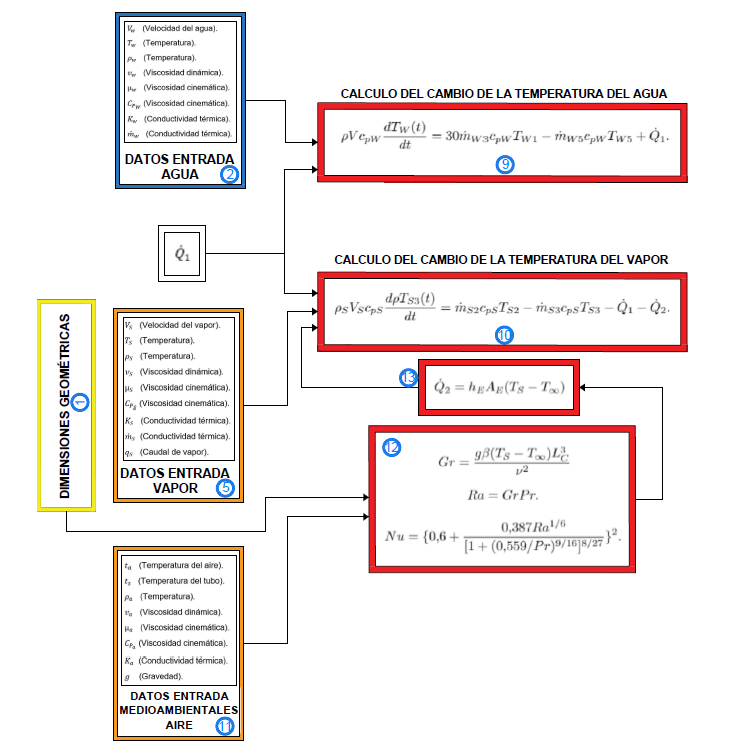

*Figura 8 : Detalle del los bloques que conforman el modelo termo fluido del condensador.*




En los sub-bloques numerados como 1, 2, y 5 se establecen las condiciones conocidas de operación del modelo tales como la velocidad, los caudales, temperaturas, viscosidad dinámica y cinemática, calores específicos y conductividad térmica de los fluidos al ingreso.
Estos valores se establecieron para el vapor de agua y agua líquida a las condiciones de operación medidas en la planta térmica real.
De igual manera, se relacionan los parámetros geométricos del condensador de vapor, tales como diámetros, la configuración del banco de tubos y las áreas internas, entre otras.

En los bloques 3 y 6, que se detallan en la figura 6, se calculan los números adimensionales necesarios para obtener los coeficientes de transferencia de calor por convección presentes en los fluidos estudiados.

En los bloques 4, 7 y 8, que se muestran en la figura 7, se solucionan las ecuaciones de transferencia de calor por conducción y por convección en los tubos.
A partir de dichas ecuaciones se determinan las temperaturas de la superficie externa e interna de los tubos que conforman el condensador de vapor.
También se calcula la transferencia de calor que fluye desde el vapor hacia el agua de refrigeración.

En los bloques 9 y 10, que se muestran en la figura 8, se solucionan las ecuaciones diferenciales ordinarias obtenidas de los balances de energía.
Se obtiene la variación de la temperatura con respecto al tiempo del vapor de agua y del agua refrigerante.
En dicha figura también se muestran los bloques 11, 12 y 13, los cuales calculan el calor que pierde el vapor hacia el medio ambiente.
Por lo tanto, en dichos bloques se solucionan los números adimensionales y la convección natural.

Todos los bloques se enlazan entre sí para dar solución al modelo de dinámica de fluidos y transferencia de calor del condensador de carcasa y tubos.

## 5. Codificación en Python

El modelo describe, en régimen transitorio, el proceso de transferencia de calor entre los gases calientes provenientes de la turbina y el agua de enfriamiento que fluye alrededor del tubo.

In [ ]:
import math
import pandas as pd

# --- Attempt to use CoolProp for higher fidelity (opcional) ---
USE_COOLPROP = False
try:
    from CoolProp.CoolProp import PropsSI
    USE_COOLPROP = True
    # print("CoolProp available: using for properties.")
except Exception:
    # print("CoolProp NOT available: using default properties.")
    USE_COOLPROP = False

# ---------- Constants ----------
g = 9.81  # m/s2

# ---------- Default Properties (fallback) ----------
def default_props_water(T=293.15, p=101325.0):
    # Values for liquid water at ~20C and 1 atm
    return {"rho": 998.2, "cp": 4182.0, "k": 0.597, "mu": 1.002e-3, "nu": 1.004e-6}

def default_props_air(T=293.15, p=101325.0):
    # Values for air at ~20C and 1 atm
    return {"rho": 1.204, "cp": 1007.0, "k": 0.0255, "mu": 1.81e-5, "nu": 1.5e-5, "beta": 1.0/T, "Pr": 0.71}

def default_props_steam_sat(T_sat=373.15, p=101325.0):
    # Values for saturated steam at ~100C and 1 atm
    # This function needs to return T_sat as well
    return {"T_sat": T_sat, "rho_v": 0.597, "h_fg": 2257000.0, "cp_v": 2010.0, "mu_v": 1.2e-5, "k_v": 0.024}

# ---------- Functions for properties (uses CoolProp if available) ----------
def props_water(T=293.15, p=101325.0):
    # Temperature in K
    if USE_COOLPROP:
        try:
            rho = PropsSI("D", "T", T, "P", p, "Water")
            cp = PropsSI("C", "T", T, "P", p, "Water")
            k = PropsSI("L", "T", T, "P", p, "Water")
            mu = PropsSI("V", "T", T, "P", p, "Water")  # dynamic Pa.s
            nu = mu / rho
            return {"rho": rho, "cp": cp, "k": k, "mu": mu, "nu": nu}
        except Exception:
            return default_props_water(T,p)
    else:
        return default_props_water(T,p)

def props_air(T=293.15, p=101325.0):
    if USE_COOLPROP:
        try:
            rho = PropsSI("D", "T", T, "P", p, "Air")
            cp = PropsSI("C", "T", T, "P", p, "Air")
            k = PropsSI("L", "T", T, "P", p, "Air")
            mu = PropsSI("V", "T", T, "P", p, "Air")
            nu = mu / rho
            beta = 1.0/T # Ideal gas assumption
            Pr = cp * mu / k
            return {"rho": rho, "cp": cp, "k": k, "mu": mu, "nu": nu, "beta": beta, "Pr": Pr}
        except Exception:
            return default_props_air(T,p)
    else:
        return default_props_air(T,p)

def props_steam_sat(T_sat=373.15, p=101325.0):
    if USE_COOLPROP:
        try:
            # returns properties at saturation (vapor)
            # If T_sat is not provided, calculate from p
            if T_sat is None and p is not None:
                T_sat = PropsSI("T", "P", p, "Q", 1, "Water")

            rho_v = PropsSI("D", "T", T_sat, "Q", 1, "Water")
            h_v = PropsSI("H", "T", T_sat, "Q", 1, "Water") # J/kg
            h_f = PropsSI("H", "T", T_sat, "Q", 0, "Water")
            h_fg = h_v - h_f
            cp_v = PropsSI("C", "T", T_sat, "Q", 1, "Water")
            mu_v = PropsSI("V", "T", T_sat, "Q", 1, "Water")
            k_v = PropsSI("L", "T", T_sat, "Q", 1, "Water")
            return {"T_sat":T_sat, "rho_v": rho_v, "h_fg": h_fg, "cp_v": cp_v, "mu_v": mu_v, "k_v": k_v}
        except Exception:
            return default_props_steam_sat(T_sat, p)
    else:
        return default_props_steam_sat(T_sat, p)

# ---------- Correlaciones ----------
def nu_natural_churchill_chu(Gr, Pr):
    # Churchill & Chu for natural convection on horizontal cylinders
    Ra = Gr * Pr
    if Ra <= 0:
        return 0.0
    term = (0.387 * Ra**(1.0/6.0)) / (1.0 + (0.559/Pr)**(9.0/16.0))**(8.0/27.0)
    Nu = (0.6 + term)**2
    return Nu

def h_natural_convection_air(T_surface, T_inf, L_c, air_props=None):
    # L_c: characteristic length (diameter for horizontal cylinder)
    T_f = (T_surface + T_inf) / 2.0
    if air_props is None:
        air_props = props_air(T_f)

    beta = air_props.get("beta", 1.0 / max(T_f, 1.0))
    nu = air_props["nu"]
    Pr = air_props["Pr"]
    k_air = air_props["k"]

    Gr = g * beta * abs(T_surface - T_inf) * (L_c**3) / (nu**2)
    Nu = nu_natural_churchill_chu(Gr, Pr)
    h = Nu * k_air / L_c
    return max(h, 1e-4) # ensure h is not zero

def overall_UA(h_steam, A_ext, h_water, A_int, k_wall, t_wall, A_wall_mean, R_fouling):
    # All areas are total areas for the section being considered
    R_steam = 1.0 / (h_steam * A_ext) if h_steam > 0 and A_ext > 0 else 1e12
    R_wall = t_wall / (k_wall * A_wall_mean) if k_wall > 0 and t_wall > 0 and A_wall_mean > 0 else 0.0
    R_water = 1.0 / (h_water * A_int) if h_water > 0 and A_int > 0 else 1e12
    R_fouling_total = R_fouling # Assuming R_fouling is given per unit area and already scaled by area

    Rtot = R_steam + R_wall + R_water + R_fouling_total
    U_overall = 1.0 / Rtot if Rtot > 0 else 0.0
    return U_overall, Rtot

def h_convection_water(Re, Pr, D_hydraulic, k_water):
    # Dittus-Boelter correlation for turbulent flow in tubes (equation 15)
    # Nu = 0.023 * Re^0.8 * Pr^0.4 (for heating fluid)
    if Re < 2300: # Laminar flow
        Nu = 3.66 # Fully developed laminar flow in circular tube
    elif Re > 10000: # Turbulent flow, typical range for Dittus-Boelter
        Nu = 0.023 * (Re**0.8) * (Pr**0.4)
    else: # Transition flow, linear interpolation or other correlations can be used. For simplicity, we use the turbulent correlation.
        Nu = 0.023 * (Re**0.8) * (Pr**0.4)

    h = Nu * k_water / D_hydraulic
    return max(h, 1e-4) # ensure h is not zero

def h_film_condensation_horizontal_tube(T_sat, T_wall, D_outer, g=9.81):
    # Film condensation correlation for a single horizontal tube (Nusselt's theory)
    # Properties of the liquid condensate film are evaluated at the film temperature
    T_film = (T_sat + T_wall) / 2.0

    liquid_props = props_water(T_film) # Liquid properties (condensate)
    steam_props = props_steam_sat(T_sat) # Steam properties (vapor)

    rho_l = liquid_props["rho"]
    mu_l = liquid_props["mu"]
    k_l = liquid_props["k"]

    rho_v = steam_props["rho_v"]
    h_fg = steam_props["h_fg"]

    delta_T = T_sat - T_wall
    if delta_T <= 0:
        return 1e-4 # Avoid division by zero or negative delta_T

    # Nusselt's correlation for horizontal tube
    h_cond = 0.729 * ((g * rho_l * (rho_l - rho_v) * k_l**3 * h_fg) / (mu_l * delta_T * D_outer))**0.25

    return max(h_cond, 1e-4)

def discretized_condenser_adapted(params):
    # Extract parameters from the dictionary
    D1 = params["D1"]          # m, diámetro interior del tubo
    D2 = params["D2"]          # m, diámetro exterior del tubo
    L = params["L"]            # m, longitud efectiva del haz de tubos y carcasa
    N_tubes = params["N_tubes"]  # Nº de tubos en el haz
    N_sections = params["N_sections"] # Nº de secciones axiales para discretización
    mdot_c = params["mdot_c"]    # kg/s, Flujo másico de agua de enfriamiento
    Tc_in = params["Tc_in"]      # K, Temperatura de entrada del agua
    m_dot_v_in = params["m_dot_v_in"] # kg/s, Flujo másico de vapor entrante
    pc = params["pc"]          # Pa, Presión dentro de la carcasa
    T_ambient = params["T_ambient"] # K, Temperatura ambiente
    k_tube = params["k_tube"]    # W/mK, conductividad térmica del material del tubo
    t_wall = params["t_wall"]    # m, espesor de la pared del tubo
    R_fouling = params["R_fouling"] # m^2K/W, Resistencia por fouling (in/out)
    phi_bank = params["phi_bank"] # Factor empírico de corrección por banco de tubos
    D_shell = params["D_shell"]

    # Derived parameters for sections
    A_int_section = (N_tubes * math.pi * D1 * L) / N_sections # A_int_total / N_sections
    A_ext_section = (N_tubes * math.pi * D2 * L) / N_sections # A_ext_total / N_sections
    A_wall_mean_section = (N_tubes * math.pi * ((D1 + D2)/2) * L) / N_sections
    A_E_total = params["A_E_total"]
    A_E_section = A_E_total / N_sections

    # Calculate saturated steam properties at condenser pressure
    steam_sat_props = props_steam_sat(p=pc)
    T_sat = steam_sat_props["T_sat"] # Get T_sat from the returned dictionary
    h_fg = steam_sat_props["h_fg"]
    rho_v_sat = steam_sat_props["rho_v"]

    # Initial conditions for the loop
    T_water_current = Tc_in
    m_dot_v_current = m_dot_v_in
    results = []

    # Mass balance for cooling water (Eq. 6)
    rho_w_in = props_water(Tc_in, params["P_ref"])[ "rho"]
    V_water_tube = (mdot_c / N_tubes) / (rho_w_in * math.pi * (D1/2.0)**2)  # Average velocity in a single tube

    for i in range(N_sections):
        # --- Cooling Water Side (Tube-side) ---
        water_props = props_water(T_water_current, params["P_ref"])
        rho_w = water_props["rho"]
        mu_w = water_props["mu"]
        k_w = water_props["k"]
        cp_w = water_props["cp"]
        Pr_w = water_props["cp"] * water_props["mu"] / water_props["k"]

        # Reynolds number for water (Eq. 7)
        Re_water = (rho_w * D1 * V_water_tube) / mu_w # Corrected: Denominator is mu_w

        # Nusselt number for water and h_W (Eq. 15 and 14)
        Nu_water = h_convection_water(Re_water, Pr_w, D1, k_w) # D1 is hydraulic diameter for internal flow
        h_W = Nu_water * k_w / D1

        # --- Iterative Loop for Condensation and Wall Temperature ---
        T_wall_prev = T_sat - (T_sat - T_water_current) * 0.2 # Initial guess for T_wall

        tolerance = 1e-3 # K
        max_iterations = 100

        # Initialize variables before loop
        h_S_i = 0.0
        U_section = 0.0 # Initialize U_section

        for iter_count in range(max_iterations):
            # Condensation heat transfer coefficient (h_S_i)
            h_S_i = h_film_condensation_horizontal_tube(T_sat, T_wall_prev, D2, g) * phi_bank

            # Resistances (inverse of conductance)
            R_steam_conv = 1.0 / (h_S_i * A_ext_section) if h_S_i > 0 and A_ext_section > 0 else 1e12
            R_wall_cond = t_wall / (k_tube * A_wall_mean_section) if k_tube > 0 and A_wall_mean_section > 0 else 1e12
            R_water_conv = 1.0 / (h_W * A_int_section) if h_W > 0 and A_int_section > 0 else 1e12
            R_fouling_val = R_fouling # Assuming R_fouling is per unit area already scaled

            R_total_from_wall_to_water = R_wall_cond + R_water_conv + R_fouling_val

            # Solve for T_wall_new based on energy balance across resistances
            if (R_steam_conv + R_total_from_wall_to_water) > 0:
                T_wall_new = (T_sat * R_total_from_wall_to_water + T_water_current * R_steam_conv) / \
                             (R_steam_conv + R_total_from_wall_to_water)
            else:
                T_wall_new = T_wall_prev # Avoid division by zero, keep previous guess

            if abs(T_wall_new - T_wall_prev) < tolerance:
                T_wall_current = T_wall_new
                break
            T_wall_prev = T_wall_new
        else:
            T_wall_current = T_wall_new # If loop finishes without convergence

        # --- Heat Loss to Ambient (Q2) ---
        h_E = h_natural_convection_air(T_sat, T_ambient, D_shell, props_air((T_sat+T_ambient)/2.0))
        Q2_section = h_E * A_E_section * (T_sat - T_ambient)

        # Refine Q1_section_val Calculation: Use heat transfer from steam to wall after convergence
        # This Q1_section_val represents the heat released by condensation
        if R_steam_conv > 0:
            Q1_section_val = (T_sat - T_wall_current) / R_steam_conv
        else:
            Q1_section_val = 0.0 # No steam side heat transfer

        # Recalculate U_section with converged values
        U_section, _ = overall_UA(h_S_i, A_ext_section, h_W, A_int_section, k_tube, t_wall, A_wall_mean_section, R_fouling)

        # --- Energy Balance for Water ---
        T_water_out = T_water_current + (Q1_section_val - Q2_section) / (mdot_c * cp_w)

        # --- Mass Balance for Steam (Eq. 9) ---
        delta_m_cond_i = Q1_section_val / h_fg
        m_dot_v_current -= delta_m_cond_i

        results.append({
            "section": i + 1,
            "T_water_in": T_water_current,
            "T_water_out": T_water_out,
            "m_dot_steam_in": m_dot_v_in if i == 0 else results[i-1]['m_dot_steam_out'],
            "m_dot_steam_out": m_dot_v_current,
            "delta_m_cond": delta_m_cond_i,
            "Q1_section": Q1_section_val,
            "Q2_section": Q2_section,
            "h_W": h_W,
            "h_S_i": h_S_i,
            "h_E": h_E,
            "U_overall": U_section,
            "T_wall": T_wall_current
        })
        T_water_current = T_water_out # Update water temperature for next section

    return results

# Example usage with default parameters
condenser_results = discretized_condenser_adapted(default_condenser_params)

# Convert results to a pandas DataFrame for better visualization
df_results = pd.DataFrame(condenser_results)
print(df_results.head())

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for plotting
sections = df_results['section']
T_water_in_profile = df_results['T_water_in']
T_water_out_profile = df_results['T_water_out']
Q1_section_profile = df_results['Q1_section']
T_wall_profile = df_results['T_wall'] # New: Wall temperature profile

# T_sat is constant for all sections, retrieve from default_condenser_params and props_steam_sat
steam_sat_props_global = props_steam_sat(p=default_condenser_params['pc'])
T_sat_constant = steam_sat_props_global["T_sat"]


# 1. Plot Temperature Profiles
plt.figure(figsize=(12, 6))
plt.plot(sections, T_water_in_profile, label='Water Inlet Temperature (K)')
plt.plot(sections, T_water_out_profile, label='Water Outlet Temperature (K)')
plt.plot(sections, T_wall_profile, label='Tube Wall Temperature (K)', linestyle='-.', color='green') # New: Wall temperature
plt.axhline(y=T_sat_constant, color='r', linestyle='--', label=f'Steam Saturation Temperature ({T_sat_constant:.2f} K)')
plt.xlabel('Condenser Section')
plt.ylabel('Temperature (K)')
plt.title('Temperature Profiles Along the Condenser')
plt.legend()
plt.grid(True)
plt.show()

# 2. Plot Heat Flux Distribution
plt.figure(figsize=(12, 6))
plt.bar(sections, Q1_section_profile, color='skyblue')
plt.xlabel('Condenser Section')
plt.ylabel('Heat Flux (W)')
plt.title('Heat Flux Distribution Along the Condenser')
plt.grid(axis='y')
plt.show()


### Simulación transitoria

In [ ]:
# Simulación transitoria condensador carcasa-tubos (Colab-ready)
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ----------------------
# DATOS BASE
# ----------------------
# Agua de enfriamiento en los tubos
water_m3_h = 100.0              # caudal volumétrico agua [m3/h]
rho_water = 997.0               # kg/m3 (agua líquida ~25°C)
vol_water_m3_s = water_m3_h / 3600.0
m_water_kg_s = vol_water_m3_s * rho_water  # caudal másico agua [kg/s]

# Vapor de agua en carcasa (desde turbina de vapor)
m_steam_in_kg_s = 5.0           # kg/s de vapor que entra al condensador
T_sat_C = 40.0                  # °C, temperatura de saturación en el condensador
T_sat_K = T_sat_C + 273.15
h_fg = 2.3e6                    # J/kg, calor latente de condensación aprox.

# Potencia máxima que se puede condensar con ese flujo de vapor (límite físico)
Q_max_cond_kW = (m_steam_in_kg_s * h_fg) / 1000.0  # kW

# ----------------------
# CONDICIONES INICIALES
# ----------------------
T_water_in_C = 25.0             # °C agua de enfriamiento a la entrada del condensador
T_water_init_K = T_water_in_C + 273.15
T_steam_K = T_sat_K             # vapor a temperatura de saturación (constante)

# ----------------------
# PROPIEDADES AGUA LADO TUBO
# ----------------------
cp_water = 4180.0   # J/kg/K
k_water = 0.6       # W/mK
mu_water = 8.9e-4   # Pa·s

# Lado carcasa (condensación de vapor): usamos un h elevado típico
h_cond_shell = 5000.0   # W/m2K, coeficiente de película de condensado (orden de magnitud)

# Presión de condensador (solo informativa si quieres usarla)
p_cond_Pa = 0.008 * 1e6   # ~8 kPa (vacío moderado)

# ----------------------
# GEOMETRÍA: UN SOLO TUBO REPRESENTATIVO
# ----------------------
N_tubes = 1
D_i = 0.050   # m diámetro interno tubo
D_o = 0.060   # m diámetro externo tubo
L = 2.0       # m longitud del tubo
D_shell = 0.5 # m diámetro carcasa

A_tube_int = math.pi * (D_i**2) / 4.0
A_tube_ext = math.pi * (D_o**2) / 4.0
A_shell_cross = math.pi * (D_shell**2) / 4.0
Area_tubes_cross = N_tubes * A_tube_ext
A_free = max(1e-6, A_shell_cross - Area_tubes_cross)  # sección libre para el condensado
wetted_perimeter = math.pi * D_o
Dh = max(1e-6, 4.0 * A_free / wetted_perimeter)       # diámetro hidráulico lado carcasa

# Área total de intercambio (lado tubo)
A_ext_total = N_tubes * math.pi * D_o * L
A_int_total = N_tubes * math.pi * D_i * L

# ----------------------
# FUNCIONES Y CORRELACIONES
# ----------------------
def reynolds(rho, D, v, mu):
    return rho * v * D / mu if mu > 0 else 0.0

def prandtl(cp, mu, k):
    return (cp * mu) / k if k > 0 else 1.0

def nu_dittus_boelter(Re, Pr):
    if Re <= 2300:
        # aquí podrías poner otra correlación para laminar, pero dejamos 3.66
        return 3.66
    return 0.023 * (Re**0.8) * (Pr**0.4)

def h_from_nusselt(Nu, k, D):
    return Nu * k / D if D > 0 else 0.0

# ----------------------
# INICIALIZACIÓN TEMPORAL
# ----------------------
T_water_K = T_water_init_K     # temperatura de masa de agua en el tubo
t_final_s = 6 * 3600           # 6 horas
dt = 0.5
n_steps = int(t_final_s / dt) + 1

times = np.linspace(0, t_final_s, n_steps)
T_water_arr = np.zeros(n_steps)
T_steam_arr = np.zeros(n_steps)
Q_arr = np.zeros(n_steps)
h_tube_arr = np.zeros(n_steps)
h_shell_arr = np.zeros(n_steps)
U_arr = np.zeros(n_steps)
m_condensed_arr = np.zeros(n_steps)   # kg/s de vapor condensado

T_water_arr[0] = T_water_K
T_steam_arr[0] = T_steam_K

# Velocidades medias
v_water = m_water_kg_s / (rho_water * A_tube_int)   # agua dentro del tubo
# Para el condensado en carcasa no definimos velocidad explícita, usamos h_cond_shell

# ----------------------
# BUCLE TEMPORAL (Euler explícito)
# ----------------------
for i in range(1, n_steps):
    # --- Lado tubos: agua de enfriamiento ---
    Re_t = reynolds(rho_water, D_i, abs(v_water), mu_water)
    Pr_t = prandtl(cp_water, mu_water, k_water)
    Nu_t = nu_dittus_boelter(Re_t, Pr_t)
    h_tube = h_from_nusselt(Nu_t, k_water, D_i)
    h_tube = max(h_tube, 50.0)  # valor mínimo razonable

    # --- Lado carcasa: condensación de vapor ---
    # Aquí simplificamos: tomamos h_shell constante elevado (condensación de película)
    h_shell = h_cond_shell

    # Resistencias térmicas
    R_conv_int = 1.0 / (h_tube * A_int_total)
    R_conv_ext = 1.0 / (h_shell * A_ext_total)
    k_wall = 16.0  # W/mK, por ejemplo acero al carbono
    R_cond = math.log(D_o / D_i) / (2.0 * math.pi * k_wall * L) if D_o > D_i else 1e6
    R_total = R_conv_int + R_cond + R_conv_ext

    U = 1.0 / (R_total * A_ext_total)
    U = max(U, 1e-12)

    # Flujo de calor instantáneo (W)
    Q_W = U * A_ext_total * (T_steam_K - T_water_K)
    Q_kW = Q_W / 1000.0

    # Límite por capacidad de vapor a condensar (por si quieres imponérselo)
    if Q_kW > Q_max_cond_kW:
        Q_kW = Q_max_cond_kW
        Q_W = Q_kW * 1000.0

    # Tasa de condensación [kg/s]
    m_condensed_kg_s = Q_W / h_fg

    # Balance de energía sobre el agua (se calienta)
    dT_water = Q_W / (m_water_kg_s * cp_water)
    T_water_K += dT_water * dt

    # Guardar historia
    T_water_arr[i] = T_water_K
    T_steam_arr[i] = T_steam_K     # permanece casi constante (Tsat)
    Q_arr[i] = Q_kW
    h_tube_arr[i] = h_tube
    h_shell_arr[i] = h_shell
    U_arr[i] = U
    m_condensed_arr[i] = m_condensed_kg_s

# ----------------------
# POSTPROCESO Y GRÁFICOS
# ----------------------
T_water_C = T_water_arr - 273.15
T_steam_C = T_steam_arr - 273.15
time_h = times / 3600.0

df_summary = pd.DataFrame({
    "t_s": times.astype(int),
    "t_h": time_h,
    "T_agua_tubos_C": np.round(T_water_C, 3),
    "T_vapor_carcasa_C": np.round(T_steam_C, 3),
    "Q_cond_kW": np.round(Q_arr, 3),
    "h_tubos_W_m2K": np.round(h_tube_arr, 3),
    "h_carcasa_W_m2K": np.round(h_shell_arr, 3),
    "U_global_W_m2K": np.round(U_arr, 8),
    "m_condensado_kg_s": np.round(m_condensed_arr, 5)
})

print("\nPrimeras 10 filas de la simulación:")
display(df_summary.head(10).T)
print("\nÚltimas 10 filas de la simulación:")
display(df_summary.tail(10).T)

plt.figure(figsize=(9,4))
plt.plot(time_h, T_water_C, label="T agua tubos (°C)")
plt.plot(time_h, T_steam_C, "--", label="T vapor carcasa (°C)")
plt.xlabel("Tiempo (h)")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9,3))
plt.plot(time_h, Q_arr, label="Q cond (kW)")
plt.xlabel("Tiempo (h)")
plt.ylabel("Q (kW)")
plt.grid(True)
plt.show()

df_props = pd.DataFrame({
    "h_tubos_mean_W_m2K": [np.mean(h_tube_arr)],
    "h_carcasa_mean_W_m2K": [np.mean(h_shell_arr)],
    "U_mean_W_m2K": [np.mean(U_arr)],
    "A_ext_total_m2": [A_ext_total],
    "m_agua_kg_s": [m_water_kg_s],
    "m_vapor_in_kg_s": [m_steam_in_kg_s],
    "m_condensado_mean_kg_s": [np.mean(m_condensed_arr)]
})
print("\nPropiedades medias calculadas:")
display(df_props.T)
